In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.pv import pv_power
from src.config import PV_RATED_KW

master = pd.read_csv(ROOT / "data" / "processed" / "master_hourly.csv", index_col=0, parse_dates=True)
fc = pd.read_csv(ROOT / "results" / "forecasts.csv", index_col=0, parse_dates=True)
load = pd.read_csv(ROOT / "data" / "processed" / "household_load_hourly.csv",
                   index_col=0, parse_dates=True)["load_kwh"]

weather = master.loc[fc.index]                      # same hours as the simulation year
pv = pv_power(weather["solar_wm2"], weather["temp_c"]).rename("pv_kwh")

print("System size (kW):", PV_RATED_KW)
print("Peak output (kW):", round(pv.max(), 2))
print("Total over the period (kWh):", round(pv.sum()))
print("Average per day (kWh):", round(pv.sum() / (len(pv) / 24), 1))
print("Zero output when sun is zero:", bool((pv[weather["solar_wm2"] == 0] == 0).all()))
pv.resample("MS").sum().round(0)

System size (kW): 6.6
Peak output (kW): 5.1
Total over the period (kWh): 7793
Average per day (kWh): 21.7
Zero output when sun is zero: True


timestamp
2025-10-01     768.0
2025-11-01     861.0
2025-12-01    1078.0
2026-01-01    1141.0
2026-02-01     863.0
2026-03-01     659.0
2026-04-01     535.0
2026-05-01     357.0
2026-06-01     249.0
2026-07-01     334.0
2026-08-01     422.0
2026-09-01     526.0
Freq: MS, Name: pv_kwh, dtype: float64

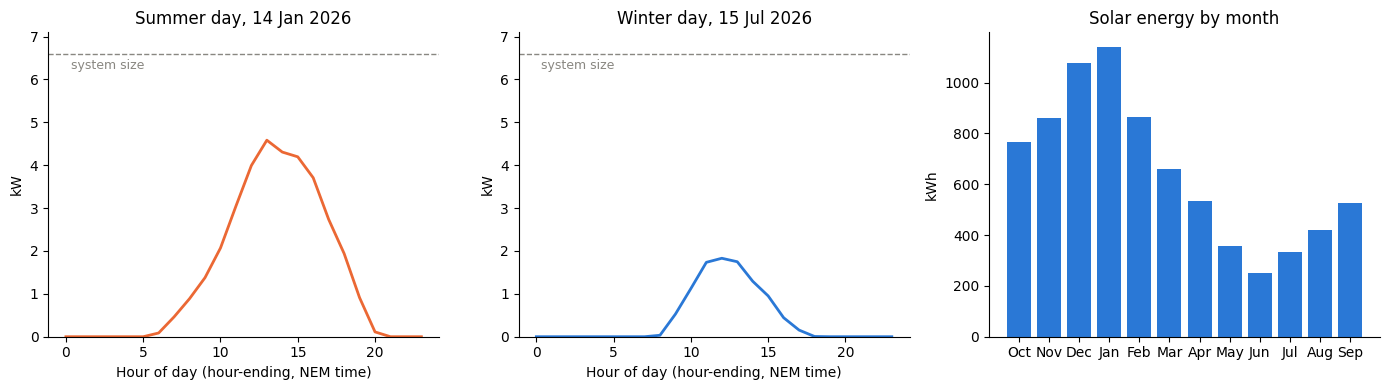

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, day, title, colour in [(axes[0], "2026-01-14", "Summer day, 14 Jan 2026", "#eb6834"),
                               (axes[1], "2026-07-15", "Winter day, 15 Jul 2026", "#2a78d6")]:
    d = pv[day]
    ax.plot(d.index.hour, d.values, color=colour, lw=2)
    ax.axhline(PV_RATED_KW, color="#898781", ls="--", lw=1)
    ax.text(0.3, PV_RATED_KW - 0.35, "system size", color="#898781", fontsize=9)
    ax.set_ylim(0, PV_RATED_KW + 0.5)
    ax.set_title(title); ax.set_xlabel("Hour of day (hour-ending, NEM time)"); ax.set_ylabel("kW")
monthly = pv.resample("MS").sum()
axes[2].bar(monthly.index.strftime("%b"), monthly.values, color="#2a78d6")
axes[2].set_title("Solar energy by month"); axes[2].set_ylabel("kWh")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ROOT / "results" / "fig_pv_model.png", dpi=150)
plt.show()

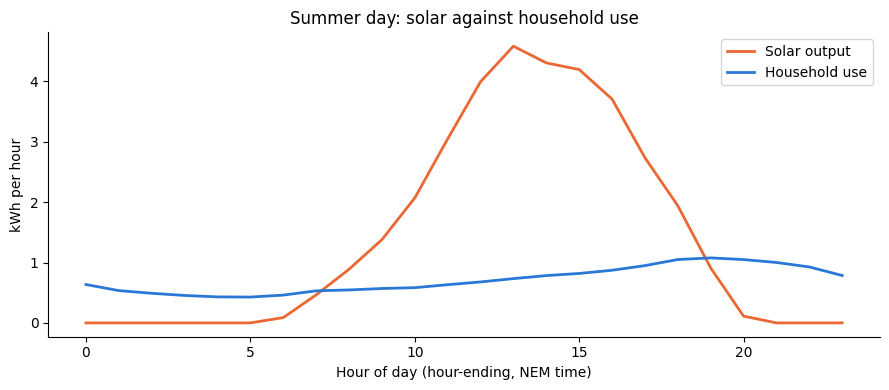

Solar used straight away: 2,467 kWh (32% of solar)
Solar left over (would be exported with no battery): 5,326 kWh (68%)


In [3]:
day = "2026-01-14"
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pv[day].index.hour, pv[day].values, color="#eb6834", lw=2, label="Solar output")
ax.plot(load[day].index.hour, load[day].values, color="#2a78d6", lw=2, label="Household use")
ax.set_xlabel("Hour of day (hour-ending, NEM time)"); ax.set_ylabel("kWh per hour")
ax.set_title("Summer day: solar against household use"); ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

direct = pd.concat([pv, load], axis=1).min(axis=1).sum()
exported = (pv - load).clip(lower=0).sum()
print(f"Solar used straight away: {direct:,.0f} kWh ({100*direct/pv.sum():.0f}% of solar)")
print(f"Solar left over (would be exported with no battery): {exported:,.0f} kWh ({100*exported/pv.sum():.0f}%)")

In [4]:
pv.to_frame().rename_axis("timestamp").to_csv(ROOT / "data" / "processed" / "pv_hourly.csv")
print(pv.shape)

(8616,)
